# Distribution Analysis

> Understanding the structure of the Diabetes 130-US dataset before running federated experiments.
> This notebook has two goals:
> 1. **Global distributions** — class-conditional feature statistics that inform what the FedGen generator *should* learn to approximate.
> 2. **Dirichlet heterogeneity** — how client distributions diverge from the global as α decreases, providing an empirical basis for the accuracy-vs-communication-cost Pareto analysis.

---

# First chapter: Clinical Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import wasserstein_distance, entropy, ks_2samp
import warnings
import sys
import os
import json

warnings.filterwarnings('ignore')
sys.path.append('..')

from UC1Utils import (
    load_data, drop_columns, remove_deceased, create_target,
    encode_features, _impute_and_group_specialty,
    prepare_data, ensure_data, CSV_MAIN, derive_global_columns, prepare_data_preohe
)
from UC1FLUtils import dirichlet_partition, find_feasible_params, preprocess_clients, verify_leakage, load_clients, create_clients_raw_csv, load_partitions_from_disk

from UC1PrintingUtils import (
    plot_class_distribution,
    plot_continuous_features,
    plot_categorical_features,
    plot_engineered_features,
    plot_feature_correlations,
)


plt.rcParams.update({
    'figure.dpi':       130,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':        11,
})
PALETTE = {'Not readmitted (0)': '#4878CF', 'Readmitted <30d (1)': '#E24A33'}
CONTINUOUS_FEATURES = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses',
    'service_utilization', 'medication_count', 'age'
]
CAT_FEATURES = [
    'discharge_disposition_id', 'admission_type_id',
    'A1Cresult', 'max_glu_serum', 'diag_1'
]
ALPHA_SWEEP = [0.1, 0.5, 1.0, 5.0,10.0]
N_CLIENTS   = 5
SEED        = 42
FEDERATED_DIR  = '../federated_data'
FILTERED_DIR   = os.path.join(FEDERATED_DIR, 'filtered')
UNFILTERED_DIR = os.path.join(FEDERATED_DIR, 'unfiltered')

os.makedirs('figures', exist_ok=True)
print('Setup complete.')

Setup complete.


## 1. Load Data

We work at two levels:
- **Raw DataFrame** (pre-OHE) — for clinical feature distributions.
- **Encoded matrix** (post-OHE) — for federated partitioning and Wasserstein analysis.

In [2]:
ensure_data()
df  = prepare_data_preohe(CSV_MAIN)
X, y, groups, feature_names = prepare_data(CSV_MAIN, verbose=True)

✓ CSV files already present, skipping extraction.
dropna removed 1518 rows (1.53%) — likely from unmapped admission_type/source IDs
Dataset shape after cleaning: (97825, 101)
Class distribution:
readmitted_binary
0    86618
1    11207
Name: count, dtype: int64
Imbalance ratio: 7.73:1  (positive rate: 11.46%)


## 2. Global Class Distribution

The 7.73:1 imbalance is the single most structurally important property of this dataset.
It directly affects what the generator must learn: class 1 is rare, so its latent
representations are also sparsely sampled during generator training.

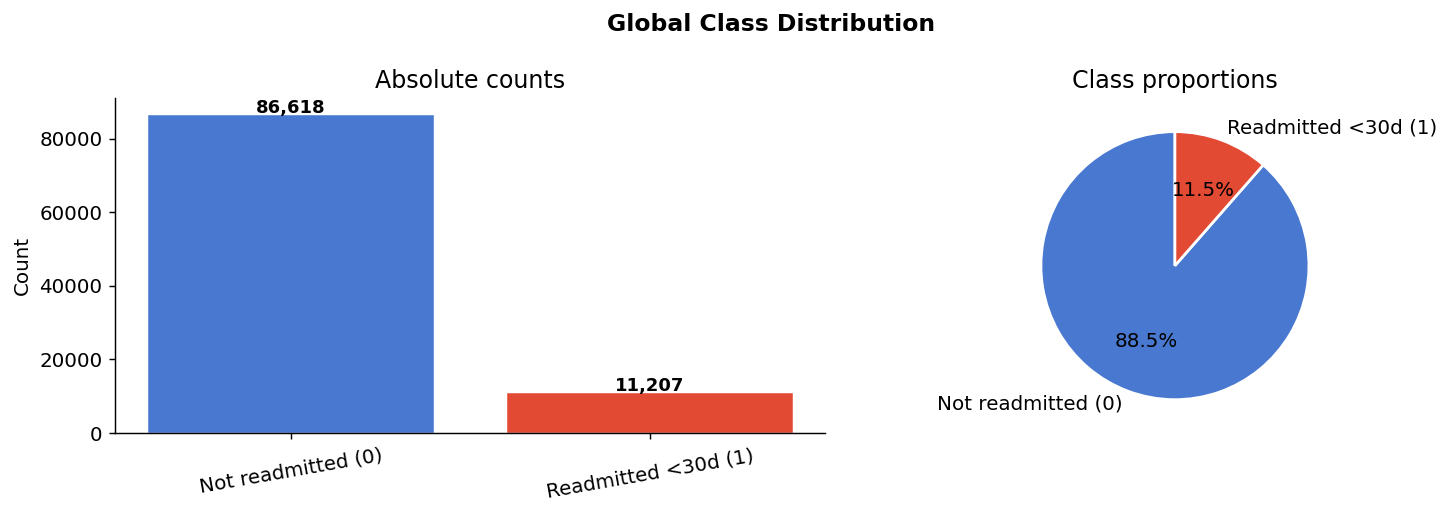

Imbalance ratio: 7.73:1  |  Positive rate: 11.46%


In [3]:
# Cell 6
plot_class_distribution(y, PALETTE)

## 3. Class-Conditional Distributions: Continuous Features

These are the features whose class-conditional distributions the generator is implicitly
trying to capture in latent space. Large separations between the two class distributions
indicate high discriminative power — and also indicate where a biased local dataset
will produce the worst model drift.

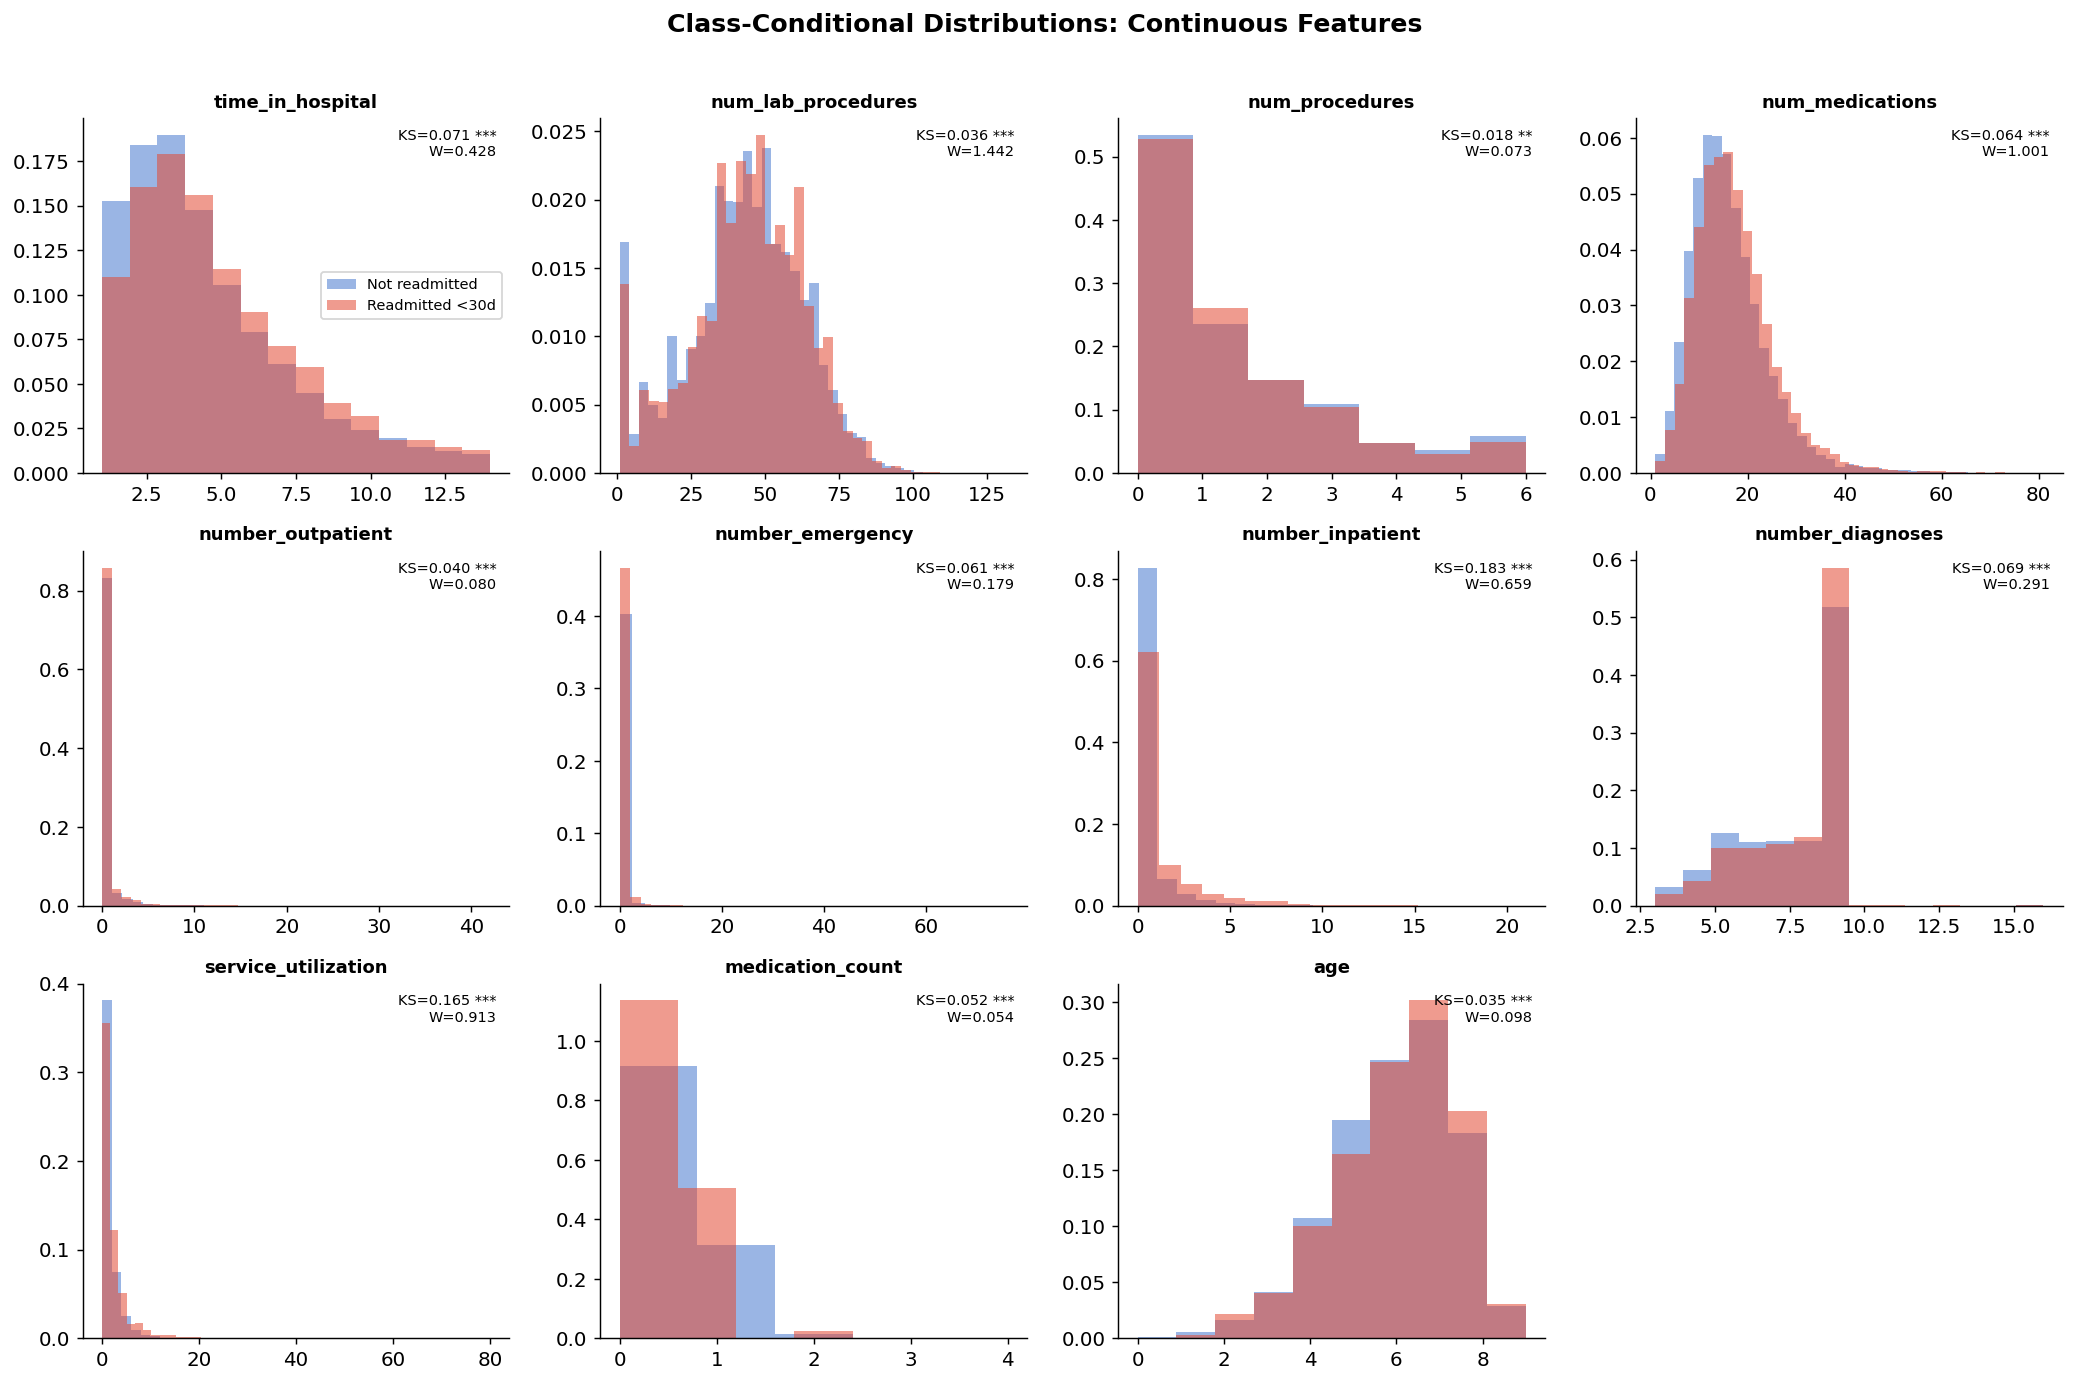

In [4]:
plot_continuous_features(df, y, CONTINUOUS_FEATURES, PALETTE)

## 4. Class-Conditional Distributions: Key Categorical Features

Categorical features after grouping. The proportions per class matter for the generator
because the label prior $\hat{p}(y)$ is used to sample labels during generator training.

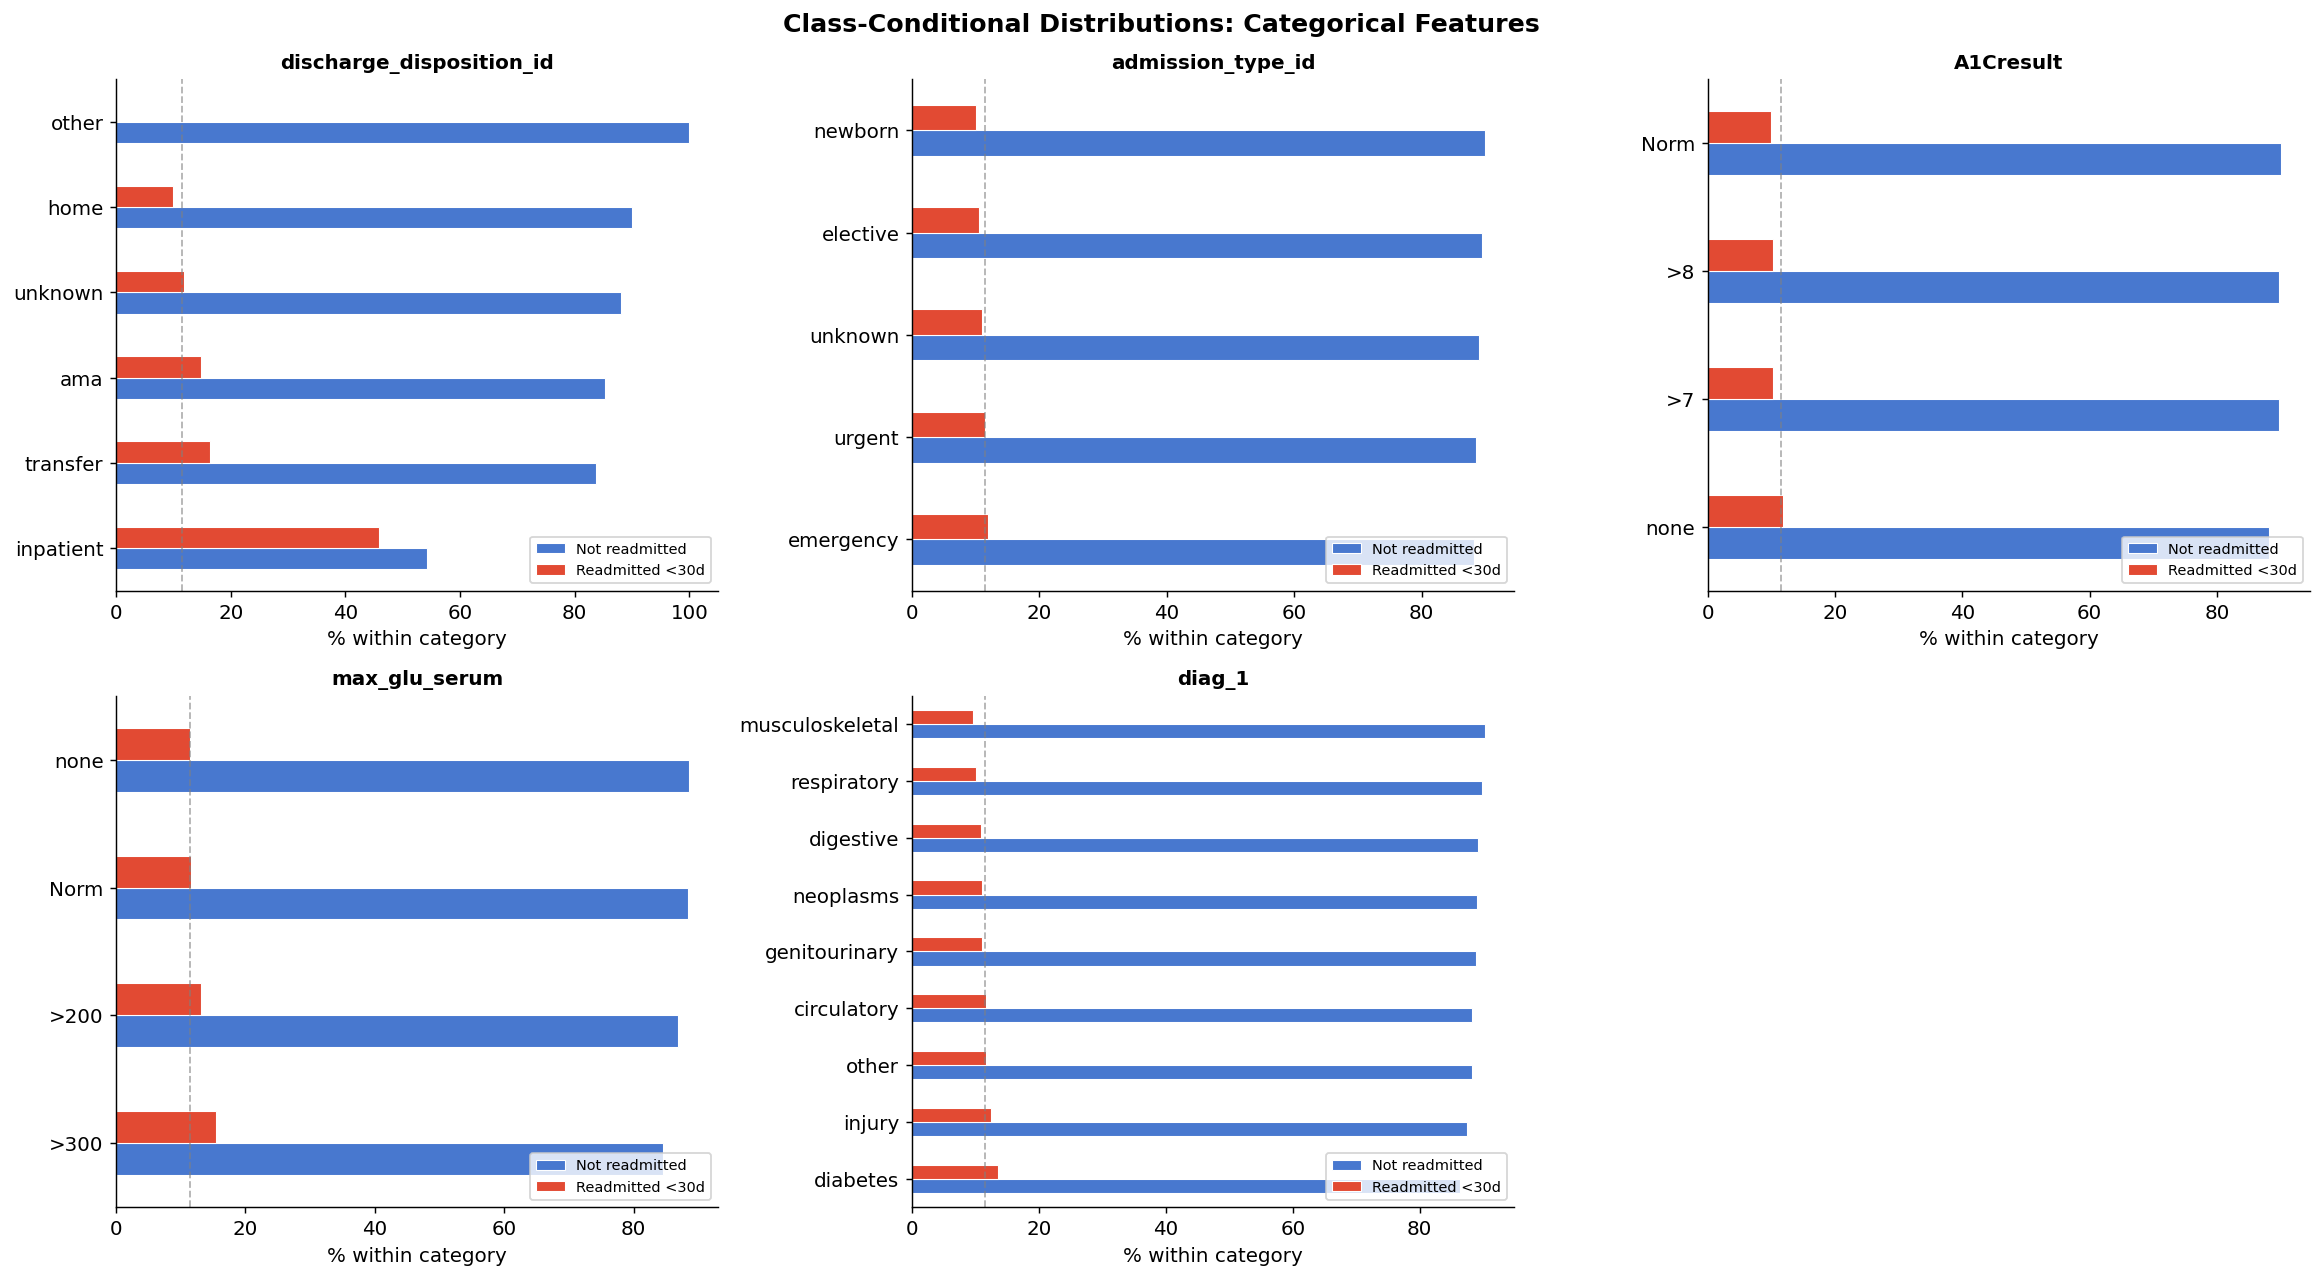

In [5]:
plot_categorical_features(df, y, CAT_FEATURES, PALETTE)

## 5. Engineered Features: Clinical Validation

These three features — `service_utilization`, `medication_count`, and
`HbA1c_diabetes_interaction` — were added based on the literature.
This section validates that they actually carry the expected signal.

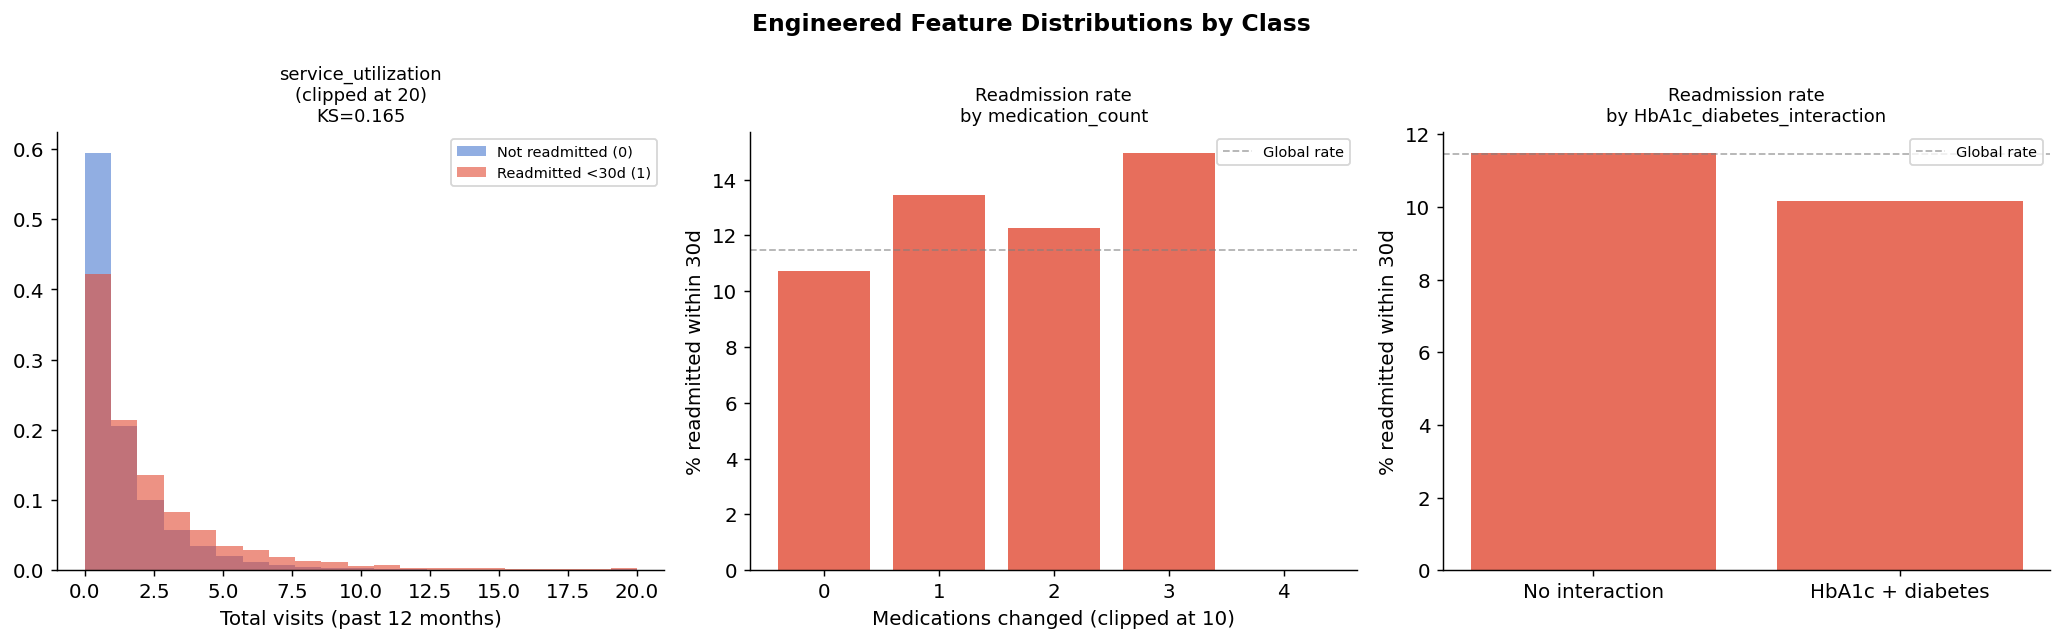

In [6]:
plot_engineered_features(df, y, PALETTE)

## 6. Feature Correlation and Redundancy

Before studying heterogeneity, it is useful to know which continuous features move together.
Highly correlated features imply that client distribution shift in one will manifest in
correlated shifts in others — the effective dimensionality of the heterogeneity is lower
than the raw feature count.

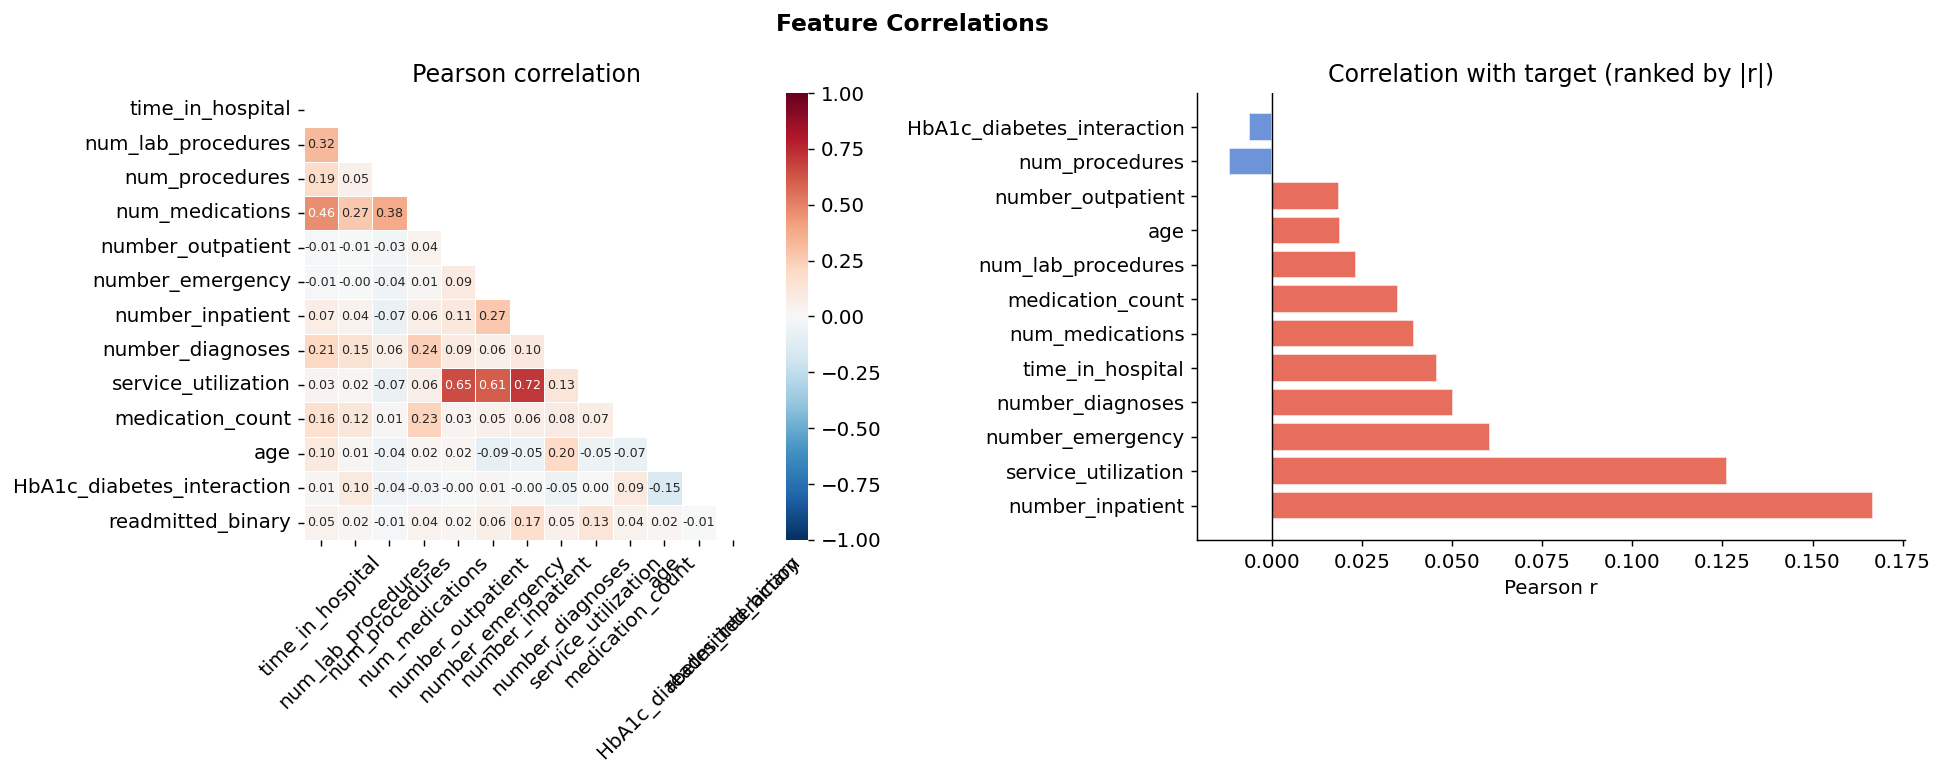

In [7]:
plot_feature_correlations(df, CONTINUOUS_FEATURES)